<a href="https://colab.research.google.com/github/Dramy8/DI_Bootcamp/blob/main/Week04/Day6/Daily/Data_Handling_and_Analysis_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download and import the Data Science Job Salary dataset.
Normalize the ‘salary’ column using Min-Max normalization which scales all salary values between 0 and 1.
Implement dimensionality reduction like Principal Component Analysis (PCA) or t-SNE to reduce the number of features (columns) in the dataset.
Group the dataset by the ‘experience_level’ column and calculate the average and median salary for each experience level (e.g., Junior, Mid-level, Senior).

In [13]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("datascience_salaries.csv")
df.head()

,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


In [4]:
scaler = MinMaxScaler()
df['salary_normalized'] = scaler.fit_transform(df[['salary']])
df

,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary,salary_normalized
0,0,Data scientist,Full Time,Senior,New York City,USD,149000,0.601010
1,2,Data scientist,Full Time,Senior,Boston,USD,120000,0.454545
2,3,Data scientist,Full Time,Senior,London,USD,68000,0.191919
3,4,Data scientist,Full Time,Senior,Boston,USD,120000,0.454545
4,5,Data scientist,Full Time,Senior,New York City,USD,149000,0.601010
...,...,...,...,...,...,...,...,...
1166,2243,ML Ops,Full Time,Senior,Toronto,USD,228000,1.000000
1167,2249,ML Ops,Full Time,Senior,Boston,USD,115000,0.429293
1168,2250,ML Ops,Full Time,Senior,Delhi,USD,76000,0.232323
1169,2255,ML Ops,Full Time,Senior,San Francisco,USD,68000,0.191919


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1171 non-null   int64  
 1   job_title          1171 non-null   object 
 2   job_type           1171 non-null   object 
 3   experience_level   1171 non-null   object 
 4   location           1171 non-null   object 
 5   salary_currency    1171 non-null   object 
 6   salary             1171 non-null   int64  
 7   salary_normalized  1171 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 73.3+ KB


PCA was not applied in this analysis because the dataset contains only one meaningful numerical feature: salary. The other numerical column, salary_normalized, is directly derived from salary and does not provide additional information. Since PCA is designed to reduce multiple correlated numerical features into a smaller set of components, applying it here would not be meaningful and would not result in a significant reduction of dimensionality.


In [9]:
salary_by_exp = df.groupby("experience_level")["salary"].agg([
    "mean",
    "median"
])

In [10]:
salary_by_exp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Entry to Senior
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    4 non-null      float64
 1   median  4 non-null      float64
dtypes: float64(2)
memory usage: 96.0+ bytes


In [11]:
salary_by_exp.columns

Index(['mean', 'median'], dtype='object')

<Figure size 800x500 with 0 Axes>

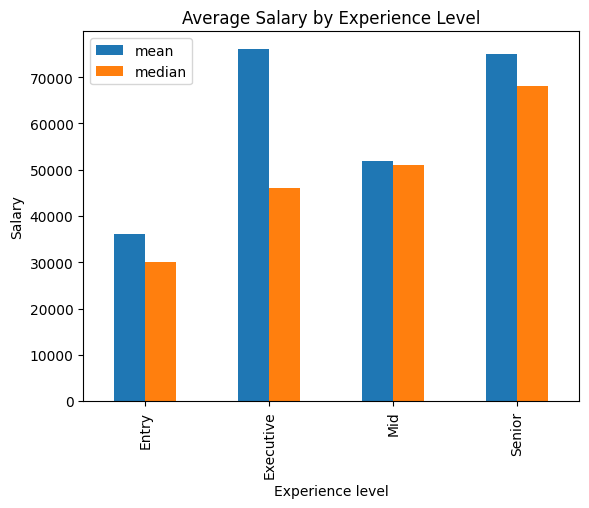

In [16]:
plt.figure(figsize=(8,5))
salary_by_exp.plot(kind="bar")
plt.title("Average Salary by Experience Level")
plt.xlabel("Experience level")
plt.ylabel("Salary")
plt.show()